In [38]:
import graphviz
import sympy as sym

from sympy.printing.dot import dotprint
from sympy import log, sin, cos, tan, sqrt, diff, Wild, Mul, Add, Function, Symbol, cse

In [39]:
def sympy_expr_to_graph(expr):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    dot = graphviz.Digraph(comment="SymPy Expression Tree")
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr):
    dot_form = dotprint(expr)
    return graphviz.Source(dot_form)

In [40]:
from sympy.abc import x, y, z
a,b,c,d,e,f = sym.symbols('a:f')
n, k        = sym.symbols('n k')
t           = Symbol('t')
mu          = Symbol('mu')
g           = Function('g')

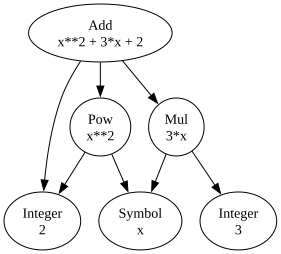

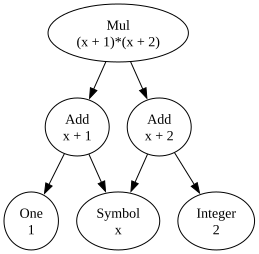

'poly_factored_tree.pdf'

In [4]:
expr1 = x**2 + 3*x + 2
display(sympy_expr_to_graph(expr1))
display(sympy_expr_to_graph(sym.factor(expr1)))
A = sympy_expr_to_graph(expr1)
A.render("poly_expanded_tree",view=False)
B = sympy_expr_to_graph(sym.factor(expr1))
B.render("poly_factored_tree",view=False)

# cancel

In [13]:
numer       = x**2 + 2*x + 1
denom       = x**2 + x
expr_cancel = numer/denom
display(sym.factor(numer))
display(sym.factor(denom))
display(expr_cancel)
display(sym.cancel(expr_cancel))

(x + 1)**2

x*(x + 1)

(x**2 + 2*x + 1)/(x**2 + x)

(x + 1)/x

# collect

In [6]:
expr_collect = x*y + x - 3 + 2*x**2 - z*x**2 + x**3
display(expr_collect)
display(sym.collect(expr_collect,x))

x**3 - x**2*z + 2*x**2 + x*y + x - 3

x**3 + x**2*(2 - z) + x*(y + 1) - 3

# combsimp

In [15]:
expr_combsimp = sym.factorial(n)/sym.factorial(n-3)
display(expr_combsimp)
display(sym.combsimp(expr_combsimp))
expr_combsimp = sym.binomial(n+1,k+1)/sym.binomial(n,k)
display(expr_combsimp)
display(sym.combsimp(expr_combsimp))

factorial(n)/factorial(n - 3)

n*(n - 2)*(n - 1)

binomial(n + 1, k + 1)/binomial(n, k)

(n + 1)/(k + 1)

# factor and factorlist

In [16]:
expr_factor = x**2*z + 4*x*y*z + 4*y**2*z
display(expr_factor)
display(sym.factor(expr_factor))
display(sym.factor_list(expr_factor))

x**2*z + 4*x*y*z + 4*y**2*z

z*(x + 2*y)**2

(1, [(z, 1), (x + 2*y, 2)])

# gammasimp

In [17]:
expr_gamma = sym.gamma(x) * sym.gamma(1-x)
display(expr_gamma)
display(sym.gammasimp(expr_gamma))

gamma(x)*gamma(1 - x)

pi/sin(pi*x)

# logcombine

In [24]:
expr_logcombine = sym.log(x) + sym.log(y)
display(expr_logcombine)
display(sym.logcombine(expr_logcombine,force=True))
expr_logcombine = n*log(x)
display(expr_logcombine)
display(sym.logcombine(expr_logcombine,force=True))

log(x) + log(y)

log(x*y)

n*log(x)

log(x**n)

# powdenest & powsimp

In [30]:
expr_powdenest = (x**a)**b
display(expr_powdenest)
display(sym.powdenest(expr_powdenest,force=True))
expr_powsimp = x**a*y**a
display(expr_powsimp)
display(sym.powsimp(expr_powsimp,force=True))

(x**a)**b

x**(a*b)

x**a*y**a

(x*y)**a

# radsimp

In [33]:
expr_radsimp = ( (2+2*sqrt(2))*x + (2+sqrt(8))*y ) / (2+sqrt(2))
display(expr_radsimp)
display(sym.radsimp(expr_radsimp))

(x*(2 + 2*sqrt(2)) + y*(2 + 2*sqrt(2)))/(sqrt(2) + 2)

sqrt(2)*(x + y)

# ratsimp

In [34]:
expr_ratsimp = 1/x + 1/y
display(expr_ratsimp)
display(sym.ratsimp(expr_ratsimp))

1/y + 1/x

(x + y)/(x*y)

# together

In [35]:
expr_together = 1/(1+1/x) + 1/(1+1/y)
display(expr_together)
display(sym.together(expr_together))

1/(1 + 1/y) + 1/(1 + 1/x)

(x*(y + 1) + y*(x + 1))/((x + 1)*(y + 1))

# trigsimp

In [37]:
expr_trigsimp = 2*sin(x)**2 + 2*cos(x)**2
display(expr_trigsimp)
display(sym.trigsimp(expr_trigsimp))

2*sin(x)**2 + 2*cos(x)**2

2